# Análisis predictivo de datos - Evaluación 1

**Condiciones de entrega de la evaluación:**

- Debe entregar un archivo en formato .ipynb.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura, solo entregue el código que de respuesta a lo que se le pide que haga.

Con el archivo de datos suministrado, va a crear un modelo de aprendizaje de máquina que prediga la variable **Weight**. Para escoger el modelo a utilizar se debe tener en cuenta que esta variable es **numérica** o **cuantitativa**.

Información sobre este archivo, incluido el diccionario de datos, la puede obtener en [Kaggle](https://www.kaggle.com/datasets/samruddhim/olympics-althlete-events-analysis).

## Carga y comprensión de los datos

Abra el archivo de datos en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargue en `Pandas` el archivo de datos.

Indique cuántas variables y registros tiene el dataset, y asegúrese que el tipo de dato de cada variable sea el esperado.

Reporte las estadísticas descriptivas de las variables numéricas y categóricas.

Identifique si el dataframe tiene datos duplicados.

Identifique si hay variables con datos nulos.

Reporte los hallazgos en un celda de texto.

In [242]:
from pathlib import Path

import pandas as pd

#Aqui se esta leyendo el archivo csv y se esta guardando en un dataframe llamado df, 

DATA_DIR = Path().resolve().parent / "data" / "raw"
FILE_PATH = "athlete_events.csv"
df = pd.read_csv(DATA_DIR / FILE_PATH,na_values=['NA'])

#es para mostrar las primeras filas del dataframe
#df.head()
#Mostrar la informacion del dataframe, como el tipo de datos de cada columna y si hay valores nulos
#df.info()

#Cambiar como esta leyendo la columna 'Total Charges' de object a float64.
#df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


<p style="color: red">Indique cuántas variables y registros tiene el dataset, y asegúrese que el tipo de dato de cada variable sea el esperado.</p>
<br><p >El dataset tiene un total de 15 columnas con 271116 registros. <br> 
los tipos de objetos son los correctos paro en Medal, existen varios nulos que aparecen como NA estos so borran en la carga de datos</p>


<p style="color: red">Reporte las estadísticas descriptivas de las variables numéricas y categóricas.<p>


In [243]:
#Estadistica de las numericas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,271116.0,68248.954396,39022.286345,1.0,34643.0,68205.0,102097.25,135571.0
Age,261642.0,25.556898,6.393561,10.0,21.0,24.0,28.00,97.0
Height,210945.0,175.338970,10.518462,127.0,168.0,175.0,183.00,226.0
Weight,208241.0,70.702393,14.348020,25.0,60.0,70.0,79.00,214.0
Year,271116.0,1978.378480,29.877632,1896.0,1960.0,1988.0,2002.00,2016.0


In [244]:
#Estadistica de las categoricas
df.describe(include="object").T

,count,unique,top,freq
Name,271116,134732,Robert Tait McKenzie,58
Sex,271116,2,M,196594
Team,271116,1184,United States,17847
NOC,271116,230,USA,18853
Games,271116,51,2000 Summer,13821
Season,271116,2,Summer,222552
City,271116,42,London,22426
Sport,271116,66,Athletics,38624
Event,271116,765,Football Men's Football,5733
Medal,39783,3,Gold,13372


<p style="color: red">Identifique si el dataframe tiene datos duplicados. </p>

In [245]:
df.duplicated().sum()

np.int64(1385)

El dataframe tiene in total de 1385 registros duplicados que deben ser eliminados.

In [246]:
df =  df.drop_duplicates()

<p style="color: red">Identifique si hay variables con datos nulos.</p>

In [247]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 269731 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      269731 non-null  int64  
 1   Name    269731 non-null  object 
 2   Sex     269731 non-null  object 
 3   Age     260416 non-null  float64
 4   Height  210917 non-null  float64
 5   Weight  208204 non-null  float64
 6   Team    269731 non-null  object 
 7   NOC     269731 non-null  object 
 8   Games   269731 non-null  object 
 9   Year    269731 non-null  int64  
 10  Season  269731 non-null  object 
 11  City    269731 non-null  object 
 12  Sport   269731 non-null  object 
 13  Event   269731 non-null  object 
 14  Medal   39772 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 32.9+ MB


In [248]:
df.isnull().sum().sort_values(ascending=False).head(5)

Medal     229959
Weight     61527
Height     58814
Age         9315
Sex            0
dtype: int64

El archivo presenta varios datos nulos en age, Height, Weight y muchos en Medal.
nulos en age = 3% del dataset
nulos en height = 21% del dataset
nulos en weight = esta es la variable predictora = 22%
nulos en medal = 84% del dataset <- se va>

In [249]:
df = df.dropna(subset=['Age'])#Revisa en la columna 'Age' si hay valores nulos y elimina esas filas. pues solo es un 3% no afecta
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 260416 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      260416 non-null  int64  
 1   Name    260416 non-null  object 
 2   Sex     260416 non-null  object 
 3   Age     260416 non-null  float64
 4   Height  210040 non-null  float64
 5   Weight  207342 non-null  float64
 6   Team    260416 non-null  object 
 7   NOC     260416 non-null  object 
 8   Games   260416 non-null  object 
 9   Year    260416 non-null  int64  
 10  Season  260416 non-null  object 
 11  City    260416 non-null  object 
 12  Sport   260416 non-null  object 
 13  Event   260416 non-null  object 
 14  Medal   39044 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.8+ MB


In [250]:
df['Weight'] = df['Weight'].fillna(value=df.Weight.mean())
df['Height'] = df['Height'].fillna(value=df.Height.mean())

Como la edad es lo que principalmente determina el peso entonces asignamos el promedio a los nulos segun la media de los que tienen esas edad.

In [251]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 260416 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      260416 non-null  int64  
 1   Name    260416 non-null  object 
 2   Sex     260416 non-null  object 
 3   Age     260416 non-null  float64
 4   Height  260416 non-null  float64
 5   Weight  260416 non-null  float64
 6   Team    260416 non-null  object 
 7   NOC     260416 non-null  object 
 8   Games   260416 non-null  object 
 9   Year    260416 non-null  int64  
 10  Season  260416 non-null  object 
 11  City    260416 non-null  object 
 12  Sport   260416 non-null  object 
 13  Event   260416 non-null  object 
 14  Medal   39044 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.8+ MB


Como solo quedan 137 registros nulos en peso, esto no afecta el modelo, seran eliminados.

Descarte las variables que considere irrelevantes para su modelo (p.e. claves primarias, variables con valores únicos, variables redundantes, entre otros).

Gestione los datos duplicados y los datos nulos. En el caso de la variable **Medal**, impute a los datos nulos el valor **No medal**.

In [252]:
df = df.set_index('ID')


In [253]:
df['Medal'] = df['Medal'].fillna(value='NOMedal')

Procedo tambien a eliminar el nombre de la persona, el comite de juegos olimpicos y el nombre del juego pues no es necesario para la prediccion

In [254]:
df = df.drop(columns=['Name', 'NOC'])

In [255]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 260416 entries, 1 to 135571
Data columns (total 12 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Sex     260416 non-null  object 
 1   Age     260416 non-null  float64
 2   Height  260416 non-null  float64
 3   Weight  260416 non-null  float64
 4   Team    260416 non-null  object 
 5   Games   260416 non-null  object 
 6   Year    260416 non-null  int64  
 7   Season  260416 non-null  object 
 8   City    260416 non-null  object 
 9   Sport   260416 non-null  object 
 10  Event   260416 non-null  object 
 11  Medal   260416 non-null  object 
dtypes: float64(3), int64(1), object(8)
memory usage: 25.8+ MB


## Análisis exploratorio de variables categóricas

Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables que no deberían incluirse en la matriz de características.
- Indiquen qué tipo de procesamiento debería recibir cada una de las variables categóricas, según su tipo y cardinalidad.

Reporte los resultados del análisis en una celda de texto.

In [256]:
var_categoricas = df.select_dtypes(include="object").columns 
for var in var_categoricas: 
    print(f'{var} : {df[var].unique()}')

Sex : ['M' 'F']
Team : ['China' 'Denmark' 'Denmark/Sweden' ... 'Dow Jones' 'Greece-4' 'Digby']
Games : ['1992 Summer' '2012 Summer' '1920 Summer' '1900 Summer' '1988 Winter'
 '1992 Winter' '1994 Winter' '1932 Summer' '2002 Winter' '1952 Summer'
 '1980 Winter' '2000 Summer' '1996 Summer' '1912 Summer' '1924 Summer'
 '2014 Winter' '1948 Summer' '1998 Winter' '2006 Winter' '2008 Summer'
 '2016 Summer' '2004 Summer' '1960 Winter' '1964 Winter' '1984 Winter'
 '1984 Summer' '1968 Summer' '1972 Summer' '1988 Summer' '1936 Summer'
 '1952 Winter' '1956 Winter' '1956 Summer' '1960 Summer' '1928 Summer'
 '1976 Summer' '1980 Summer' '1964 Summer' '2010 Winter' '1968 Winter'
 '1972 Winter' '1976 Winter' '1924 Winter' '1904 Summer' '1906 Summer'
 '1928 Winter' '1908 Summer' '1948 Winter' '1932 Winter' '1936 Winter'
 '1896 Summer']
Season : ['Summer' 'Winter']
City : ['Barcelona' 'London' 'Antwerpen' 'Paris' 'Calgary' 'Albertville'
 'Lillehammer' 'Los Angeles' 'Salt Lake City' 'Helsinki' 'Lake Placid

<p style="color: red">Variables nominales</p>

Todas las categoricas a excepcion de Medal.

<p style="color: red">Variables oridnales</p>

Principalmente Medal debe asignarse como ordinal y dependiendo del contexto del estudio podriamos determinar a la season y el deporte como variables ordinales, esto porque algunos deportes exigen mayor peso a sus jugadores (como el yudo), y las temporadas afectan el metabolismo y retencion de grasas del deportista (pero no se aplicara en esta ocasion).

<p style="color: red">Alta cardinalidad</p>

<p style="color: white">Las variables City, Games,Event, Sport, Teams presentan una alta cardinalidad.</p>

In [257]:
df = df.drop(columns=['City', 'Games', 'Team', 'Event', 'Sport'])

<p style="color: red">Variables que no deberian incluirse</p>

No deberian incluirse City, pues la ciudad no afecta, ni Games, pues la fecha del juego es irrelevante, ni Team, tampoco el nombre del jugador ni el nombre del comite de asociacion de los juegos olimpicos ni el evento al que se asistio.
El deporte queda bajo investigacion pues aunque tiene una alta cardinalidad, este puede llegar a tener relevancia en el peso del deportista.

<p style="color: red">Indiquen qué tipo de procesamiento debería recibir cada una de las variables categóricas, según su tipo y cardinalidad.</p>

La variable Medal debe pasar por transformacion ordinal, las otras por procesamiento oneHotEncoder.

## Análisis exploratorio de variables cuantitativas o numéricas

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.
- Variables que no deberían incluirse en la matriz de características.
- Indique qué tipo de procesamiento debería recibir cada una de las variables numéricas, según su distribución y la presencia de valores atípicos.

Reporte los resultados del análisis en una celda de texto.

In [258]:
#Saber que tan cerca a la normal esta(entre mas cercana 0 mas normal es)
for num in df.select_dtypes(include=['number']).columns:
    print(f"Kurtosis de {num}: {df[num].kurt():.3f} \n")

Kurtosis de Age: 5.174 

Kurtosis de Height: 0.930 

Kurtosis de Weight: 3.297 

Kurtosis de Year: 0.019 



<p style="color: red">Variables que son aproximadamente normales.</p>

Las variables Height y Year son aproximadamente normales

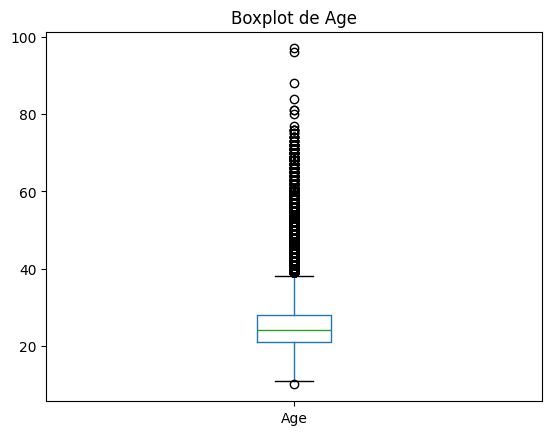

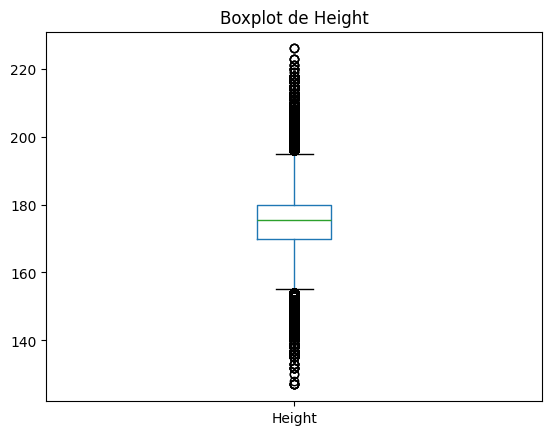

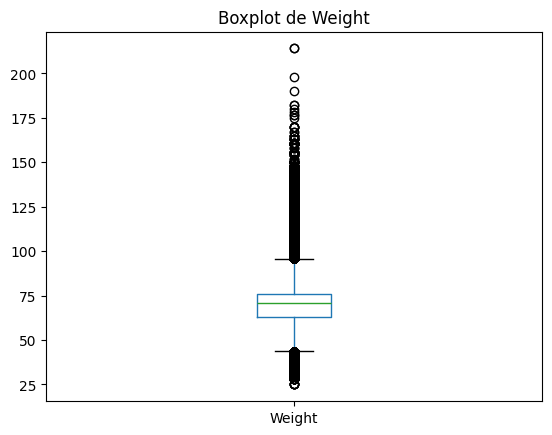

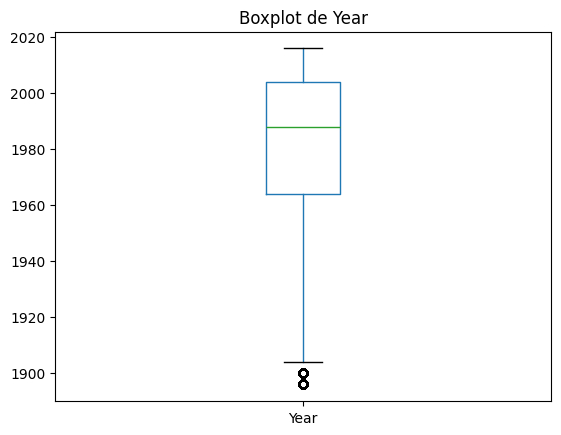

In [259]:
import matplotlib.pyplot as plt

# Boxplot en variables cuantitativas para identificar outliers
num_vars = df.select_dtypes(include='number').columns

for var in num_vars:
    plt.figure()              # crea una nueva figura
    df.boxplot(column=var, grid=False)
    plt.title(f'Boxplot de {var}')
    plt.show()

<p style="color: red">Variables con datos atípicos.</p>

Todas las variables a excepcion de Year tienen una gran cantidad de outliers o datos atipicos

<p style="color: red">Variables que no deberían incluirse en la matriz de características..</p>

Weight debe retirarse de los datos de prueba por ser la variable a predecir. 

<Axes: >

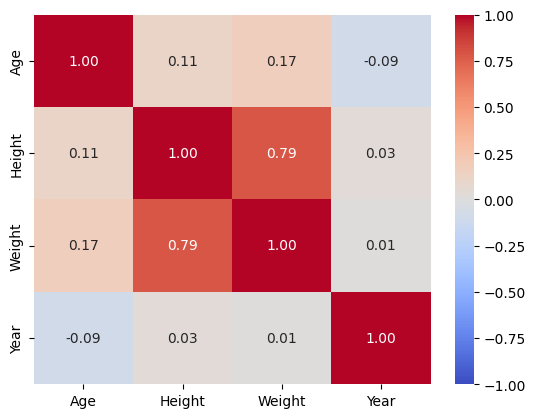

In [260]:
import seaborn as sns
corr = df.select_dtypes('number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)

Adicionalmente la correlacion entre el peso y el Year es casi cero, por lo que no es util como variable predictora

In [261]:
df = df.drop(columns=['Year'])

<p style="color: red">Indique qué tipo de procesamiento debería recibir cada una de las variables numéricas, según su distribución y la presencia de valores atípicos.</p>

In [262]:
for num in df.select_dtypes(include=['number']).columns:
    print(f"Asimetría de {num}: {df[num].skew():.3f} \n")

Asimetría de Age: 1.562 

Asimetría de Height: 0.021 

Asimetría de Weight: 0.892 



La variable Age debe pasar por estandarizacion, mientras que las otras siendo tan cerca a una distribucion normal deben pasar por transformacion Power

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Height'}>,
        <Axes: title={'center': 'Weight'}>],
       [<Axes: >, <Axes: >, <Axes: >]], dtype=object)

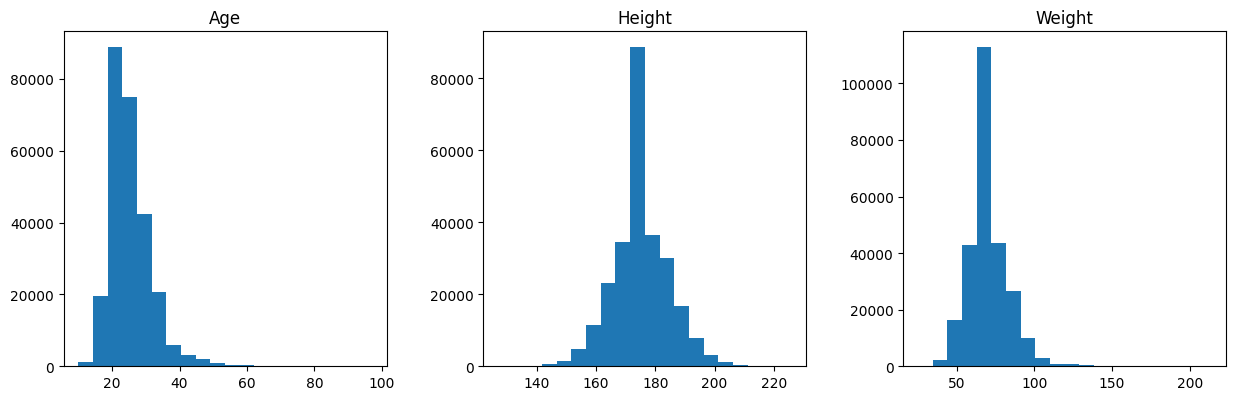

In [263]:
#Saber si tienen distribucion normal(histograma)
df.select_dtypes('number').hist(bins=20, figsize=(15,10), grid=False, layout=(2,3))

## Procesamiento de las características y entrenamiento del modelo

- Escoja un modelo de árbol de decisión que prediga la variable **Weight**, teniendo en cuenta que es numérica continua.
- Extraiga la matriz de características y el vector objetivo de su dataframe, a partir de los análisis previos.
- Parta los datos en subconjuntos de entrenamiento y de prueba.
- Procese las características del modelo usando `ColumnTransformer`.
- Entrene el modelo.
- Reporten los **scores** de entrenamiento y de prueba.
- Reporten el listado completo de características con las que fue entrenado el modelo después del procesamiento realizado.

In [264]:

from sklearn.model_selection import train_test_split

y = df['Weight']
X = df.drop(['Weight'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, train_size=0.7)
print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (182291, 5)
Tamaño del conjunto de prueba es: (78125, 5)


In [265]:
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    PowerTransformer,#normaliza
    StandardScaler,#estandariza
)

# Primero se definen los preprocesadores para cada tipo de variable para luego usarlos en las variables correspondientes

ss = StandardScaler()
pt = PowerTransformer() 
orden = ['NOMedal', 'Bronze','Silver', 'Gold']
ore = OrdinalEncoder(categories=[orden], dtype='int') 
ohe = OneHotEncoder(sparse_output=False, drop='if_binary') 

In [266]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 182291 entries, 16222 to 67105
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Sex     182291 non-null  object 
 1   Age     182291 non-null  float64
 2   Height  182291 non-null  float64
 3   Season  182291 non-null  object 
 4   Medal   182291 non-null  object 
dtypes: float64(2), object(3)
memory usage: 8.3+ MB


In [ ]:
from sklearn.compose import ColumnTransformer


preprocessor = ColumnTransformer(transformers=[
    ('num_prep', pt, ['Height']),
    ('num_prep2', ss, ['Age']),  
    ('cod_education', ore, ['Medal']), 
#    ('cod_oh', ohe, ['Sex'])
    ('cod_oh', ohe, ['Season', 'Sex'])
    ], remainder='drop')

podria retirar age porque su colinealindad con weight es de tan solo el 17%, quitarlo no ha afectado mi resultado actual del modelo que es una precision del 63%

La presencia y ausnecia de Season tampoco afecta la calidad del modelo.

In [268]:
preprocessor

,transformers,"[('num_prep', ...), ('num_prep2', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,method,'yeo-johnson'
,standardize,True
,copy,True


In [269]:
preprocessor.fit(X_train)
X_train_prep = preprocessor.transform(X_train)
X_test_prep = preprocessor.transform(X_test)

In [270]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(
    max_depth=5,
    random_state=1
    )

tree.fit(X_train_prep, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [271]:
print(f'Accuracy en el conjunto de entrenamiento: {tree.score(X_train_prep, y_train)}')
print(f'Accuracy en el conjunto de prueba: {tree.score(X_test_prep, y_test)}')

Accuracy en el conjunto de entrenamiento: 0.6397392499355719
Accuracy en el conjunto de prueba: 0.6429469332796123


In [272]:
print(preprocessor.get_feature_names_out())

['num_prep__Height' 'num_prep2__Age' 'cod_education__Medal'
 'cod_oh__Sex_M']
